In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Path to the original test datasets
test_data_path = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/data/wcsph_flows/testing/noObstacle"

# Get all HDF5 files
test_files = sorted([f for f in os.listdir(test_data_path) if f.endswith('.hdf5')])
print(f"Found {len(test_files)} test files:")
for i, file in enumerate(test_files):
    print(f"  {i}: {file}")

Found 4 test files:
  0: output_none_TGV_128x2x1.0_2024_11_04-16_04_04.hdf5
  1: output_none_TGV_128x2x2.0_2024_11_04-15_18_30.hdf5
  2: output_none_TGV_128x2x3.0_2024_11_04-16_50_45.hdf5
  3: output_none_TGV_128x2x4.0_2024_11_04-17_37_25.hdf5


In [2]:
def analyze_hdf5_file(filepath):
    """Analyze structure and basic info of an HDF5 file"""
    with h5py.File(filepath, 'r') as f:
        print(f"\n=== ANALYZING: {os.path.basename(filepath)} ===")
        
        # Print top-level keys
        print(f"Top-level keys: {list(f.keys())}")
        
        # Analyze initial conditions
        if 'initial' in f:
            print("\n--- Initial Conditions ---")
            if 'fluid' in f['initial']:
                fluid_initial = f['initial']['fluid']
                print(f"Initial fluid keys: {list(fluid_initial.keys())}")
                if 'positions' in fluid_initial:
                    positions = fluid_initial['positions'][:]
                    print(f"Initial particle count: {positions.shape[0]}")
                    print(f"Spatial dimensions: {positions.shape[1]}D")
                    print(f"Position range X: [{positions[:, 0].min():.3f}, {positions[:, 0].max():.3f}]")
                    print(f"Position range Y: [{positions[:, 1].min():.3f}, {positions[:, 1].max():.3f}]")
                    
                if 'velocities' in fluid_initial:
                    velocities = fluid_initial['velocities'][:]
                    vel_mag = np.linalg.norm(velocities, axis=1)
                    print(f"Initial velocity magnitude range: [{vel_mag.min():.6f}, {vel_mag.max():.6f}]")
        
        # Analyze simulation export (timesteps)
        if 'simulationExport' in f:
            sim_export = f['simulationExport']
            timestep_keys = [key for key in sim_export.keys() if key.isdigit()]
            timestep_keys = sorted(timestep_keys, key=int)
            
            print(f"\n--- Simulation Export ---")
            print(f"Number of timesteps: {len(timestep_keys)}")
            print(f"First timestep: {timestep_keys[0]}")
            print(f"Last timestep: {timestep_keys[-1]}")
            
            if len(timestep_keys) > 0:
                # Check first timestep structure
                first_step = sim_export[timestep_keys[0]]
                print(f"Timestep keys: {list(first_step.keys())}")
                
                if 'fluidPosition' in first_step:
                    positions = first_step['fluidPosition'][:]
                    print(f"Particles per timestep: {positions.shape[0]}")
                    
                # Check a few random timesteps for consistency
                sample_steps = [timestep_keys[0], timestep_keys[len(timestep_keys)//2], timestep_keys[-1]]
                print(f"\nSampling timesteps for consistency check:")
                for step in sample_steps:
                    if step in sim_export:
                        pos = sim_export[step]['fluidPosition'][:]
                        vel = sim_export[step]['fluidVelocity'][:]
                        dens = sim_export[step]['fluidDensity'][:]
                        print(f"  Step {step}: {pos.shape[0]} particles, pos_range=[{pos.min():.3f}, {pos.max():.3f}], vel_mag_max={np.linalg.norm(vel, axis=1).max():.3f}")
        
        return len(timestep_keys) if 'simulationExport' in f else 0

# Analyze all test files
total_frames = 0
for file in test_files:
    filepath = os.path.join(test_data_path, file)
    frames = analyze_hdf5_file(filepath)
    total_frames += frames

print(f"\n🎯 SUMMARY:")
print(f"Total files: {len(test_files)}")
print(f"Total frames across all files: {total_frames}")
print(f"Average frames per file: {total_frames / len(test_files):.1f}")


=== ANALYZING: output_none_TGV_128x2x1.0_2024_11_04-16_04_04.hdf5 ===
Top-level keys: ['config', 'initial', 'simulationExport']

--- Initial Conditions ---
Initial fluid keys: ['UID', 'areas', 'densities', 'masses', 'positions', 'potential', 'velocities']
Initial particle count: 16384
Spatial dimensions: 2D
Position range X: [-0.496, 0.496]
Position range Y: [-0.496, 0.496]
Initial velocity magnitude range: [0.023391, 1.999996]

--- Simulation Export ---
Number of timesteps: 4096
First timestep: 00001
Last timestep: 04096
Timestep keys: ['UID', 'fluidDensity', 'fluidPosition', 'fluidShiftAmount', 'fluidVelocity']
Particles per timestep: 16384

Sampling timesteps for consistency check:
  Step 00001: 16384 particles, pos_range=[-0.496, 0.496], vel_mag_max=1.999
  Step 02049: 16384 particles, pos_range=[-1.941, 1.937], vel_mag_max=1.635
  Step 04096: 16384 particles, pos_range=[-2.883, 3.172], vel_mag_max=1.419

=== ANALYZING: output_none_TGV_128x2x2.0_2024_11_04-15_18_30.hdf5 ===
Top-le


=== PLOTTING SAMPLES FROM: output_none_TGV_128x2x4.0_2024_11_04-17_37_25.hdf5 ===
Available timesteps: 4096 (from 00001 to 04096)
Plotting frames: [500, 750, 1000, 1500, 1750, 2000]
  Frame 500: 16384 particles, vel_max=1.562, density_range=[1.0, 1.0]
  Frame 750: 16384 particles, vel_max=1.377, density_range=[1.0, 1.0]
  Frame 1000: 16384 particles, vel_max=1.219, density_range=[1.0, 1.0]
  Frame 1500: 16384 particles, vel_max=0.994, density_range=[1.0, 1.0]
  Frame 1750: 16384 particles, vel_max=0.931, density_range=[1.0, 1.0]
  Frame 2000: 16384 particles, vel_max=0.841, density_range=[1.0, 1.0]


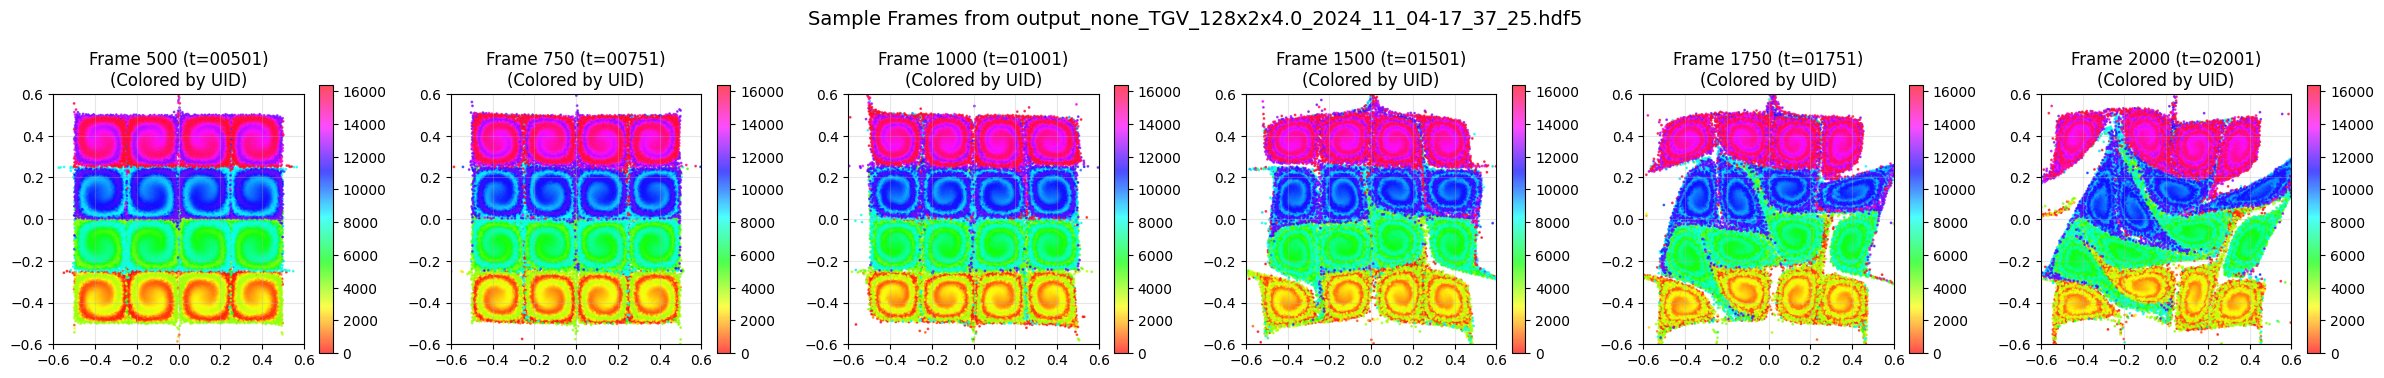


=== PLOTTING SAMPLES FROM: output_none_TGV_128x2x4.0_2024_11_04-17_37_25.hdf5 ===
Available timesteps: 4096 (from 00001 to 04096)
Plotting frames: [2500, 2750, 3000, 3500, 3750, 4000]
  Frame 2500: 16384 particles, vel_max=0.783, density_range=[1.0, 1.0]
  Frame 2750: 16384 particles, vel_max=0.683, density_range=[1.0, 1.0]
  Frame 3000: 16384 particles, vel_max=0.624, density_range=[1.0, 1.0]
  Frame 3500: 16384 particles, vel_max=0.528, density_range=[1.0, 1.0]
  Frame 3750: 16384 particles, vel_max=0.476, density_range=[1.0, 1.0]
  Frame 4000: 16384 particles, vel_max=0.448, density_range=[1.0, 1.0]


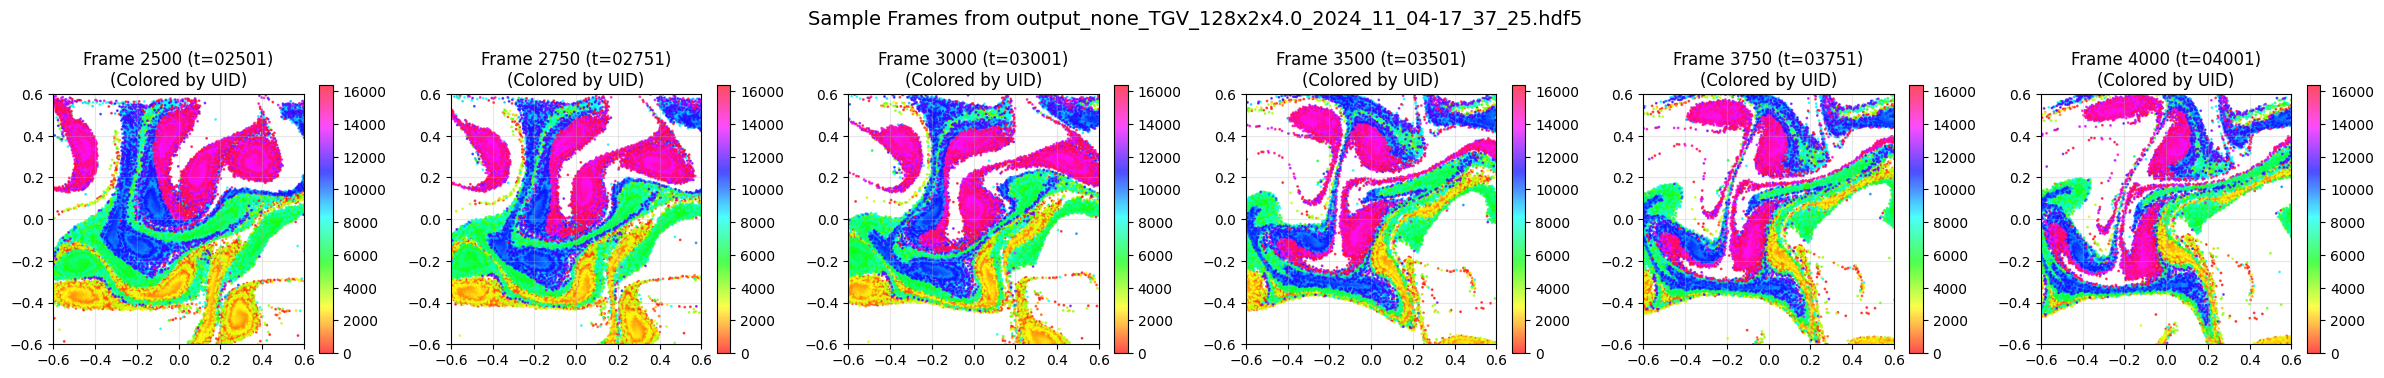

In [3]:
def plot_sample_frames(filepath, sample_frames=[0, 50, 100, 150, 200]):
    """Plot sample frames from a dataset to check trajectory consistency"""
    
    with h5py.File(filepath, 'r') as f:
        if 'simulationExport' not in f:
            print(f"No simulation export found in {filepath}")
            return
            
        sim_export = f['simulationExport']
        timestep_keys = sorted([key for key in sim_export.keys() if key.isdigit()], key=int)
        
        print(f"\n=== PLOTTING SAMPLES FROM: {os.path.basename(filepath)} ===")
        print(f"Available timesteps: {len(timestep_keys)} (from {timestep_keys[0]} to {timestep_keys[-1]})")
        
        # Filter sample frames to available range
        max_frame = len(timestep_keys) - 1
        valid_sample_frames = [f for f in sample_frames if f <= max_frame]
        print(f"Plotting frames: {valid_sample_frames}")
        
        # Create plot
        fig, axes = plt.subplots(1, len(valid_sample_frames), figsize=(4*len(valid_sample_frames), 4))
        if len(valid_sample_frames) == 1:
            axes = [axes]
        
        for i, frame_idx in enumerate(valid_sample_frames):
            timestep_key = timestep_keys[frame_idx]
            timestep_data = sim_export[timestep_key]
            
            # Get particle data
            positions = timestep_data['fluidPosition'][:]
            velocities = timestep_data['fluidVelocity'][:]
            densities = timestep_data['fluidDensity'][:]
            
            # Get UIDs for coloring (to track particles)
            if 'UID' in timestep_data:
                uids = timestep_data['UID'][:]
                colors = uids
                title_suffix = "(Colored by UID)"
            else:
                # Fallback to density
                colors = densities
                title_suffix = "(Colored by Density)"
            
            # Plot
            scatter = axes[i].scatter(positions[:, 0], positions[:, 1], 
                                    c=colors, cmap='hsv', s=1.0, alpha=0.7)
            axes[i].set_title(f'Frame {frame_idx} (t={timestep_key})\n{title_suffix}')
            axes[i].set_aspect('equal')
            axes[i].set_xlim(-0.6, 0.6)
            axes[i].set_ylim(-0.6, 0.6)
            axes[i].grid(True, alpha=0.3)
            
            # Add colorbar
            plt.colorbar(scatter, ax=axes[i], shrink=0.8)
            
            # Print frame info
            vel_mag = np.linalg.norm(velocities, axis=1)
            print(f"  Frame {frame_idx}: {positions.shape[0]} particles, "
                  f"vel_max={vel_mag.max():.3f}, density_range=[{densities.min():.1f}, {densities.max():.1f}]")
        
        plt.suptitle(f'Sample Frames from {os.path.basename(filepath)}', fontsize=14)
        plt.tight_layout()
        plt.show()

# Plot samples from the first test file
first_file = os.path.join(test_data_path, test_files[3])
plot_sample_frames(first_file, sample_frames=[500, 750, 1000, 1500, 1750, 2000])
plot_sample_frames(first_file, sample_frames=[2500, 2750, 3000, 3500, 3750, 4000])

Created dataset:
  Train: 85 trajectories
  Test: 43 trajectories
  Total: 128 trajectories

Inspecting trajectory_000.hdf5:
  Timesteps: 128 (from 00000 to 00127)
    Frame 0: 16384 particles
    Frame 30: 16384 particles
    Frame 50: 16384 particles
    Frame 100: 16384 particles
    Frame 125: 16384 particles


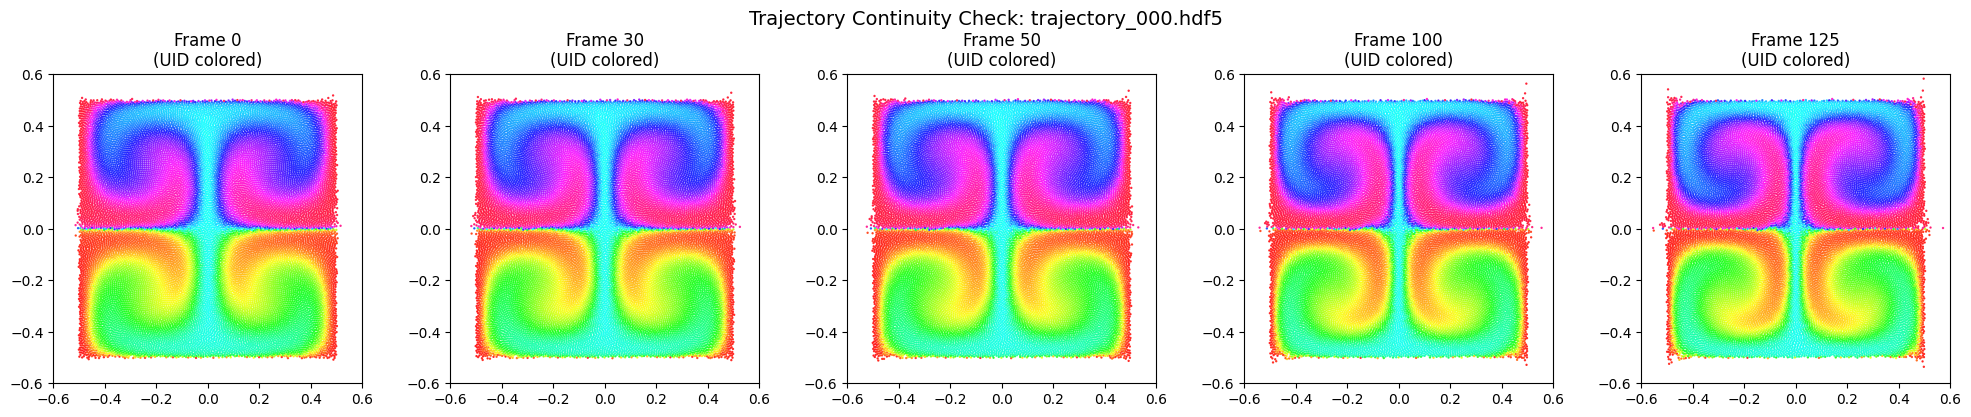

In [4]:
# Notebook cell to inspect the newly created dataset
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Paths to the newly created dataset
train_path = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/data/SFBC/SFBC_TGV/dataset/train"
test_path = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/data/SFBC/SFBC_TGV/dataset/test"

# Quick inspection
train_files = sorted([f for f in os.listdir(train_path) if f.endswith('.hdf5')])
test_files = sorted([f for f in os.listdir(test_path) if f.endswith('.hdf5')])

print(f"Created dataset:")
print(f"  Train: {len(train_files)} trajectories")
print(f"  Test: {len(test_files)} trajectories")
print(f"  Total: {len(train_files) + len(test_files)} trajectories")

# Test trajectory continuity - sample a few frames from first train trajectory
sample_file = os.path.join(test_path, test_files[39])
with h5py.File(sample_file, 'r') as f:
    print(f"\nInspecting {train_files[0]}:")
    
    timesteps = sorted([k for k in f['simulationExport'].keys() if k.isdigit()])
    print(f"  Timesteps: {len(timesteps)} (from {timesteps[0]} to {timesteps[-1]})")
    
    # Plot a few frames to check continuity
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    sample_frames = [0, 30, 50, 100, 125]
    
    for i, frame_idx in enumerate(sample_frames):
        if frame_idx < len(timesteps):
            timestep = timesteps[frame_idx]
            data = f['simulationExport'][timestep]
            
            positions = data['fluidPosition'][:]
            if 'UID' in data:
                colors = data['UID'][:]
                title_suffix = "(UID colored)"
            else:
                colors = data['fluidDensity'][:]
                title_suffix = "(Density colored)"
            
            scatter = axes[i].scatter(positions[:, 0], positions[:, 1], 
                                    c=colors, cmap='hsv', s=0.5, alpha=0.8)
            axes[i].set_title(f'Frame {frame_idx}\n{title_suffix}')
            axes[i].set_aspect('equal')
            axes[i].set_xlim(-0.6, 0.6)
            axes[i].set_ylim(-0.6, 0.6)
            
            print(f"    Frame {frame_idx}: {positions.shape[0]} particles")
    
    plt.suptitle(f'Trajectory Continuity Check: {train_files[0]}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [5]:
import torch

# Debug: Load frames the same way as training/plotting code
from BasisConvolution.util.dataloader import datasetLoader, processFolder
from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.hyperparameters import defaultHyperParameters, parseHyperParameters, finalizeHyperParameters
from BasisConvolution.util.arguments import parser
import shlex

# Setup hyperparameters exactly like training
hyperParameterDict = defaultHyperParameters()
hyperParameterDict['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
hyperParameterDict['augmentAngle'] = False
hyperParameterDict['augmentJitter'] = False
hyperParameterDict['maxRollOut'] = 0

args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --basisFunctions ffourier --basisTerms 4 --windowFunction None --maxUnroll 0 --frameDistance 0 --epochs 1'))
hyperParameterDict = parseHyperParameters(args, None)
hyperParameterDict['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load test dataset exactly like training
test_datasetPath = '/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/data/SFBC/SFBC_TGV/dataset/test'
test_ds = datasetLoader(processFolder(hyperParameterDict, test_datasetPath))
finalizeHyperParameters(hyperParameterDict, test_ds)

print(f"Dataset size: {len(test_ds)} total frames")

diffSPH not available, will use sphMath for config parsing
Unroll length  1  exceeds maximum, limiting to 0
Dataset size: 5504 total frames


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:740: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


In [6]:
# Check how many frames per trajectory the dataset thinks there are
test_files = [f for f in os.listdir(test_datasetPath) if f.endswith('.hdf5')]
with h5py.File(os.path.join(test_datasetPath, test_files[0]), 'r') as f:
    timestep_groups = [key for key in f['simulationExport'].keys() if key.isdigit()]
    frames_per_trajectory = len(timestep_groups)

print(f"Files on disk: {len(test_files)} trajectories")
print(f"Frames per file: {frames_per_trajectory}")
print(f"Expected total frames: {len(test_files) * frames_per_trajectory}")
print(f"Dataset loader sees: {len(test_ds)} frames")

# Check if there's a mismatch
if len(test_ds) != len(test_files) * frames_per_trajectory:
    print("WARNING: Frame count mismatch between files and dataset loader!")

Files on disk: 43 trajectories
Frames per file: 128
Expected total frames: 5504
Dataset loader sees: 5504 frames


In [7]:
# Check which frames the dataset loader is actually loading
print("Investigating which frames are loaded by dataset loader...")

# Get the file list that the dataset loader processed
train_ds_debug = datasetLoader(processFolder(hyperParameterDict, test_datasetPath))

# Check the internal structure of the dataset loader
if hasattr(test_ds, 'files') or hasattr(test_ds, 'fileList'):
    files_attr = getattr(test_ds, 'files', getattr(test_ds, 'fileList', None))
    print(f"Dataset files attribute: {type(files_attr)}")
    if files_attr and len(files_attr) > 0:
        print(f"First few files: {files_attr[:3]}")

# Check internal frame mapping
if hasattr(test_ds, 'sampleList') or hasattr(test_ds, 'samples'):
    samples_attr = getattr(test_ds, 'sampleList', getattr(test_ds, 'samples', None))
    if samples_attr:
        print(f"Sample list length: {len(samples_attr)}")
        print(f"First few samples: {samples_attr[:5]}")
        print(f"Last few samples: {samples_attr[-5:]}")

Investigating which frames are loaded by dataset loader...


In [8]:
# Check frame range per trajectory
frames_per_traj_actual = []
current_file = None
frame_count = 0

# Try to map dataset indices to files
for i in range(min(300, len(test_ds))):  # Check first 300 frames
    try:
        config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(i, test_ds, hyperParameterDict)
        
        # Try to get file info from config or attributes
        if hasattr(config, 'fileName') or (isinstance(config, dict) and 'fileName' in config):
            file_name = config.get('fileName') if isinstance(config, dict) else config.fileName
            
            if file_name != current_file:
                if current_file is not None:
                    frames_per_traj_actual.append(frame_count)
                    print(f"Trajectory {current_file}: {frame_count} frames")
                current_file = file_name
                frame_count = 1
            else:
                frame_count += 1
                
    except Exception as e:
        print(f"Error at frame {i}: {e}")
        break

if current_file is not None:
    frames_per_traj_actual.append(frame_count)
    print(f"Trajectory {current_file}: {frame_count} frames")

if frames_per_traj_actual:
    print(f"Frames per trajectory (actual): {frames_per_traj_actual[:5]}...")
    print(f"Average frames per trajectory: {np.mean(frames_per_traj_actual):.1f}")

Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  ex

In [9]:
# Direct check: Compare first trajectory's frames between file and dataset loader
test_file_0 = os.path.join(test_datasetPath, test_files[0])
print(f"Checking first trajectory: {test_files[0]}")

# Direct file access
with h5py.File(test_file_0, 'r') as f:
    file_timesteps = sorted([k for k in f['simulationExport'].keys() if k.isdigit()])
    print(f"File has timesteps: {len(file_timesteps)} ({file_timesteps[0]} to {file_timesteps[-1]})")

# Dataset loader access for first trajectory
print("Dataset loader frames for first trajectory:")
traj_0_frames = []
for i in range(130):  # Check more than 128 to see the boundary
    try:
        config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(i, test_ds, hyperParameterDict)
        
        # Get time or timestep info if available
        time_info = "unknown"
        if hasattr(config, 'time'):
            time_info = f"t={config.time}"
        elif isinstance(config, dict) and 'time' in config:
            time_info = f"t={config['time']}"
        elif hasattr(attributes, 'time'):
            time_info = f"t={attributes.time}"
            
        traj_0_frames.append((i, time_info))
        
    except Exception as e:
        print(f"Frame {i}: Error - {e}")
        break

print(f"Dataset loader sees {len(traj_0_frames)} frames for first trajectory")
if len(traj_0_frames) < 128:
    print(f"Missing frames: {128 - len(traj_0_frames)}")

Checking first trajectory: trajectory_014.hdf5
File has timesteps: 128 (00000 to 00127)
Dataset loader frames for first trajectory:
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, 

In [10]:
# Check processFolder function behavior
print("Checking processFolder parameters...")

# Re-run processFolder with debug info
processed_files = processFolder(hyperParameterDict, test_datasetPath)
print(f"processFolder returned {len(processed_files)} processed files")

for i, file_data in enumerate(processed_files[:3]):
    print(f"\nFile {i}:")
    for key, value in file_data.items():
        if key == 'samples':
            print(f"  {key}: {len(value) if hasattr(value, '__len__') else type(value)} samples")
            if hasattr(value, '__len__') and len(value) > 0:
                print(f"    Range: {min(value)} to {max(value)}")
        elif key == 'frames':
            print(f"  {key}: {len(value) if hasattr(value, '__len__') else type(value)} frames") 
            if hasattr(value, '__len__') and len(value) > 0:
                print(f"    Range: {min(value)} to {max(value)}")
        else:
            print(f"  {key}: {value}")

Checking processFolder parameters...
processFolder returned 43 processed files

File 0:
  fileName: /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/data/SFBC/SFBC_TGV/dataset/test/trajectory_000.hdf5
  frames: 128 frames
    Range: 0 to 127
  samples: 128 samples
    Range: 00000 to 00127
  frameDistance: 0
  frameSpacing: 1
  maxRollout: 0
  skip: 0
  limit: -1
  isTemporalData: True
  style: newFormat

File 1:
  fileName: /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/data/SFBC/SFBC_TGV/dataset/test/trajectory_001.hdf5
  frames: 128 frames
    Range: 0 to 127
  samples: 128 samples
    Range: 00000 to 00127
  frameDistance: 0
  frameSpacing: 1
  maxRollout: 0
  skip: 0
  limit: -1
  isTemporalData: True
  style: newFormat

File 2:
  fileName: /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/data/SFBC/SFBC_TGV/dataset/test/trajectory_002.hdf5
  frames: 128 frames
    Range: 0 to 127
  samples: 128 samples
    Range: 00000 to 00127
  frameDistance: 0

In [11]:
# Fix the frame indexing calculation
frames_per_trajectory_actual = 127  # What dataset loader actually sees
random_trajectory_idx = 41

# Recalculate with correct frame count
trajectory_start_idx = random_trajectory_idx * frames_per_trajectory_actual
frames_to_plot = [0, 30, 50, 100, 126]  # Changed 125 to 126 (max frame)
actual_frames = [trajectory_start_idx + f for f in frames_to_plot]

print(f"Corrected calculation:")
print(f"  Trajectory {random_trajectory_idx} starts at dataset index: {trajectory_start_idx}")
print(f"  Frame offsets: {frames_to_plot}")
print(f"  Actual dataset indices: {actual_frames}")
print(f"  Max valid index: {len(test_ds) - 1}")

# Verify all indices are valid
all_valid = all(idx < len(test_ds) for idx in actual_frames)
print(f"  All indices valid: {all_valid}")

Corrected calculation:
  Trajectory 41 starts at dataset index: 5207
  Frame offsets: [0, 30, 50, 100, 126]
  Actual dataset indices: [5207, 5237, 5257, 5307, 5333]
  Max valid index: 5503
  All indices valid: True


Unroll length  8  exceeds maximum, limiting to 0
Frame 0 (idx=5207): 16384 particles
Unroll length  8  exceeds maximum, limiting to 0
Frame 30 (idx=5237): 16384 particles
Unroll length  8  exceeds maximum, limiting to 0
Frame 50 (idx=5257): 16384 particles
Unroll length  8  exceeds maximum, limiting to 0
Frame 100 (idx=5307): 16384 particles
Unroll length  8  exceeds maximum, limiting to 0
Frame 126 (idx=5333): 16384 particles


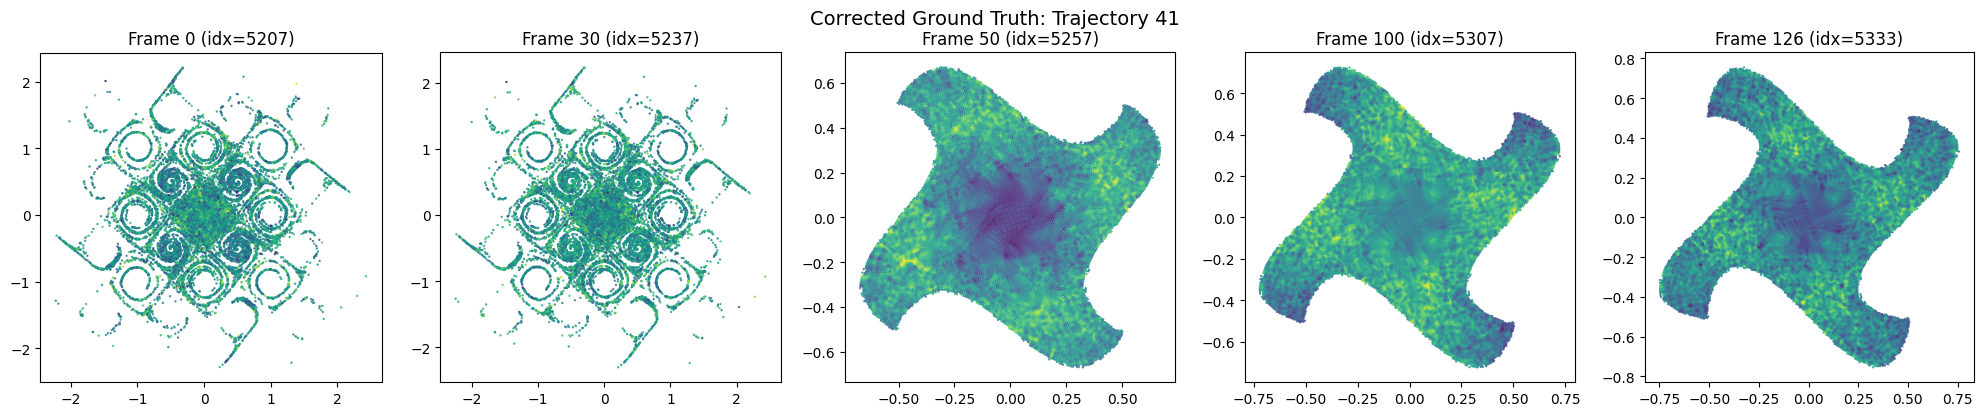

In [12]:
# Test the corrected frame loading
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, frame_idx in enumerate(actual_frames):
    config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(frame_idx, test_ds, hyperParameterDict)
    
    positions = currentState['fluid']['positions'].cpu().numpy()
    
    if trajectoryStates and len(trajectoryStates) > 0:
        gt = trajectoryStates[0]['fluid']['target']
        if isinstance(gt, torch.Tensor):
            gt = gt.cpu().numpy()
        gt_density = gt[:, 0] if gt.shape[1] > 0 else gt.flatten()
    else:
        gt_density = np.ones(len(positions))
    
    scatter = axes[i].scatter(positions[:, 0], positions[:, 1], 
                            c=gt_density, cmap='viridis', s=0.5, alpha=0.8)
    axes[i].set_title(f'Frame {frames_to_plot[i]} (idx={frame_idx})')
    axes[i].set_aspect('equal')
    
    print(f"Frame {frames_to_plot[i]} (idx={frame_idx}): {positions.shape[0]} particles")

plt.suptitle(f'Corrected Ground Truth: Trajectory {random_trajectory_idx}', fontsize=14)
plt.tight_layout()
plt.show()